# Cargar y preparar el dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import numpy as np
import random
from transformers import set_seed

def fix_all_seeds(seed=42):
    # Semilla para librerías estándar
    random.seed(seed)
    np.random.seed(seed)

    # Semilla para PyTorch (CPU y GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Semilla específica de Transformers (afecta a inicialización de pesos y dropout)
    set_seed(seed)

    # Garantizar determinismo en algoritmos de la GPU (puede ralentizar un poco)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Semilla {seed} fijada globalmente.")

fix_all_seeds(42)

Semilla 42 fijada globalmente.


In [3]:
import json
import pandas as pd
from datasets import Dataset, DatasetDict
from sklearn.model_selection import GroupShuffleSplit

def load_and_split_grouped_dataset(path, test_size=0.1, val_size=0.1, seed=42):
    # 1. Cargar el archivo JSONL a un DataFrame de Pandas
    with open(path, 'r', encoding='utf-8') as f:
        data = [json.loads(line) for line in f]
    df = pd.DataFrame(data)

    # --- MULTIMODAL: Atomicity filter - discard incomplete groups ---
    valid_mask = df.groupby('group_id').filter(
        lambda g: g['title'].notna().all() and g['img_text'].notna().all()
                  and len(g) == 2
    ).index
    df = df.loc[valid_mask].reset_index(drop=True)
    # --- END MULTIMODAL ---

   # 1. División Train vs Test
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_idx, test_idx = next(gss.split(df, groups=df['group_id']))
    df_train_total = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    # 2. División Train vs Validation
    val_relative_size = val_size / (1 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=seed)
    train_final_idx, val_idx = next(gss_val.split(df_train_total, groups=df_train_total['group_id']))

    # 3. BARAJADO EXPLÍCITO
    # .sample(frac=1) desordena todas las filas. reset_index evita conflictos de índices.
    train_df = df_train_total.iloc[train_final_idx].sample(frac=1, random_state=seed).reset_index(drop=True)
    val_df = df_train_total.iloc[val_idx].sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df = df_test.sample(frac=1, random_state=seed).reset_index(drop=True)

    return DatasetDict({
        'train': Dataset.from_pandas(train_df),
        'validation': Dataset.from_pandas(val_df),
        'test': Dataset.from_pandas(test_df)
    })

path_dataset = '/content/drive/MyDrive/TFG/titles_img_data.jsonl'
dataset = load_and_split_grouped_dataset(path_dataset)

In [4]:
# Comptobacion
train_ids = set(dataset['train']['group_id'])
test_ids = set(dataset['test']['group_id'])

# La intersección debe ser un conjunto vacío
overlap = train_ids.intersection(test_ids)
print(f"Coincidencias de IDs entre train y test: {len(overlap)}")

Coincidencias de IDs entre train y test: 0


In [6]:
from transformers import AutoTokenizer

model_checkpoint = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

import string
import re

# Flag para controlar el experimento
STRIP_PUNCTUATION = False

def clean_text(text):
    # 1. Convertir a minúsculas (opcional, ayuda a normalizar)
    text = text.lower()
    # 2. Eliminar puntuación usando regex y la librería string
    # Esto elimina: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Eliminar espacios múltiples resultantes
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_function(examples):
    if STRIP_PUNCTUATION:
        texts = [clean_text(t) + ' [SEP] ' + c for t, c in zip(examples['title'], examples['img_text'])]
    else:
        texts = [t + ' [SEP] ' + c for t, c in zip(examples['title'], examples['img_text'])]

    return tokenizer(texts, truncation=True, padding='max_length', max_length=256)

tokenized_dataset = dataset.map(preprocess_function, batched=True)
print(f"Dataset features: {tokenized_dataset['train'].features}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1402 [00:00<?, ? examples/s]

Map:   0%|          | 0/176 [00:00<?, ? examples/s]

Map:   0%|          | 0/176 [00:00<?, ? examples/s]

Dataset features: {'group_id': Value('string'), 'title': Value('string'), 'is_real': Value('int64'), 'img_path': Value('string'), 'img_text': Value('string'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [7]:
print(tokenized_dataset['train']['is_real'][:100])

[0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0]


# Cargar modelo y ejecutar entrenamiento


## Definir funciones de metricas

In [8]:
!pip install evaluate

In [9]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Aplicar softmax para obtener probabilidades para AUC
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    auc = roc_auc_score(labels, probs)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'auc': auc
    }

Para la optimización de hiperparámetros se implementó un Weights & Biases Sweep empleando Optimización Bayesiana. Este enfoque permite modelar la función de pérdida mediante un proceso Gaussiano, optimizando la búsqueda en el espacio de parámetros (Search Space) y convergiendo hacia el mínimo global de forma más eficiente que un muestreo aleatorio (Random Search).

In [10]:
tokenized_dataset = tokenized_dataset.rename_column('is_real', 'labels')

In [12]:
import wandb
import re
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback

sweep_config = {
    'method': 'random',
    'metric': {'name': 'eval_f1', 'goal': 'maximize'},
    'parameters': {
        'learning_rate': {
            'distribution': 'log_uniform_values',
            'min': 1e-6,
            'max': 2e-5
        },
        'weight_decay': {
            'values': [0.01, 0.05, 0.1]
        },
        'num_train_epochs': {
            'values': [3, 5]
        },
        'warmup_ratio': {
            'values': [0.1, 0.15]
        },
        'per_device_train_batch_size': {
            'values': [8, 16]
        }
    }
}

sweep_id = wandb.sweep(sweep_config, project="tfg-roberta-img-tuning")

def train_iteration():
    with wandb.init(config={"image_context": True}):
        config = wandb.config

        id2label = {0: "SYNTHETIC", 1: "REAL"}
        label2id = {"SYNTHETIC": 0, "REAL": 1}

        model = AutoModelForSequenceClassification.from_pretrained(
            "FacebookAI/roberta-base",
            num_labels=2,
            id2label=id2label,
            label2id=label2id
        )

        args = TrainingArguments(
            output_dir="./temp_checkpoints",
            report_to="wandb",
            learning_rate=config.learning_rate,
            num_train_epochs=config.num_train_epochs,
            per_device_train_batch_size=config.per_device_train_batch_size,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="f1"
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=tokenized_dataset["train"],
            eval_dataset=tokenized_dataset["validation"],
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

        trainer.train()

wandb.agent(sweep_id, function=train_iteration, count=5)

Create sweep with ID: 2abnreju
Sweep URL: https://wandb.ai/javierprior04-universidad-de-murcia/tfg-roberta-img-tuning/sweeps/2abnreju


wandb: Agent Starting Run: z3uyjbjn with config:
wandb: 	learning_rate: 1.391830088225436e-05
wandb: 	num_train_epochs: 5
wandb: 	per_device_train_batch_size: 16
wandb: 	warmup_ratio: 0.15
wandb: 	weight_decay: 0.1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: WARNING Config item 'per_device_train_batch_size' was locked by 'sweep' (ignored update).
wand

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

eval/accuracy,▁▆███
eval/auc,▁▄███
eval/f1,▁▇███
eval/loss,█▆▁▁▁
eval/precision,█▁▅▆▆
eval/recall,▁████
eval/runtime,▃▇▁▁█
eval/samples_per_second,▆▂██▁
eval/steps_per_second,▆▂██▁
train/epoch,▁▃▅▆██
+1,...


In [15]:
import wandb

api = wandb.Api()

sweep = api.sweep(f"javierprior04-universidad-de-murcia/tfg-roberta-img-tuning/{sweep_id}")

best_run = sweep.best_run()

if best_run:
    print("Mejor configuración encontrada:")
    print(f"  Run ID: {best_run.id}")
    print(f"  F1 Score: {best_run.summary.get('eval_f1')}")
    for key, value in best_run.config.items():
        print(f"  {key}: {value}")
else:
    print("No se encontró ninguna mejor ejecución. Asegúrate de que el sweep haya terminado y haya registrado métricas.")

# Debugging prints
print(f"\nDebugging best_run object: {best_run}")
if best_run:
    print(f"Debugging best_run.config: {best_run.config}")
    print(f"Debugging best_run.summary: {best_run.summary}")

wandb: Sorting runs by -summary_metrics.eval_f1


Mejor configuración encontrada:
  Run ID: 2jjh9zfs
  F1 Score: None
  bf16: False
  fp16: False
  fsdp: []
  seed: 42
  tf32: None
  debug: []
  dtype: float32
  optim: adamw_torch_fused
  do_eval: True
  project: huggingface
  use_cpu: False
  do_train: False
  id2label: {'0': 'SYNTHETIC', '1': 'REAL'}
  label2id: {'REAL': 1, 'SYNTHETIC': 0}
  run_name: None
  data_seed: None
  deepspeed: None
  hub_token: <HUB_TOKEN>
  log_level: passive
  max_steps: -1
  report_to: ['wandb']
  use_cache: False
  adam_beta1: 0.9
  adam_beta2: 0.999
  do_predict: False
  eval_delay: 0
  eval_steps: None
  hidden_act: gelu
  is_decoder: False
  local_rank: -1
  model_type: roberta
  optim_args: None
  output_dir: ./temp_checkpoints
  save_steps: 500
  vocab_size: 50265
  ddp_backend: None
  ddp_timeout: 1800
  fsdp_config: {'xla': False, 'xla_fsdp_v2': False, 'min_num_params': 0, 'xla_fsdp_grad_ckpt': False}
  hidden_size: 768
  label_names: None
  logging_dir: None
  push_to_hub: False
  return_dict: 

## Entrenar con los mejores hyperparametros

In [18]:
# --- CELDA DE ENTRENAMIENTO FINAL ---

# 1. Configura aquí los mejores parámetros encontrados por el Sweep
best_config = {
    "learning_rate": 7.34386048770094e-06,
    "num_train_epochs": 3,
    "batch_size": 16 # per_device_train_batch_size from sweep
}

id2label = {0: "SYNTHETIC", 1: "REAL"}
label2id = {"SYNTHETIC": 0, "REAL": 1}

model_final = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/roberta-base",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

final_args = TrainingArguments(
    seed=42,
    data_seed=42,
    full_determinism=True,
    output_dir="./resultados_finales",
    learning_rate=best_config["learning_rate"],
    num_train_epochs=best_config["num_train_epochs"],
    per_device_train_batch_size=best_config["batch_size"],
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=False,
    warmup_ratio=0.1, # Añadido de la configuración del sweep
    weight_decay=0.01 # Añadido de la configuración del sweep
)

trainer = Trainer(
    model=model_final,
    args=final_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

eval_test = trainer.evaluate(tokenized_dataset["test"])
print(f"Resultados en el conjunto de TEST: {eval_test}")

import os

save_path = "/content/drive/MyDrive/TFG/modelos/roberta-imgs"

trainer.save_model(save_path)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,No log,0.582565,0.784091,0.728571,0.980769,0.579545,0.919163
2,No log,0.354535,0.886364,0.879518,0.935897,0.829545,0.948735
3,No log,0.298604,0.892045,0.887574,0.925926,0.852273,0.957903


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Resultados en el conjunto de TEST: {'eval_loss': 0.2733536660671234, 'eval_accuracy': 0.9147727272727273, 'eval_f1': 0.9101796407185628, 'eval_precision': 0.9620253164556962, 'eval_recall': 0.8636363636363636, 'eval_auc': 0.9610020661157025, 'eval_runtime': 2.9745, 'eval_samples_per_second': 59.169, 'eval_steps_per_second': 7.396, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Tras el trainer.train()
predictions = trainer.predict(tokenized_dataset["test"])
logits = predictions.predictions
labels = predictions.label_ids
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

# Con esto ya puedes usar sklearn y matplotlib para:
# 1. ConfusionMatrixDisplay
# 2. RocCurveDisplay
# 3. PrecisionRecallDisplay

- Analizar errores (Error Analysis): No te quedes solo en el número. Crea una celda que extraiga los 10 titulares donde el modelo falló con más confianza (falsos positivos/negativos "seguros"). Esto es oro para la sección de Discusión de tu TFG.

- Calibration Plot: Verifica si el modelo es "honesto". Si dice que un titular es sintético con un 90% de probabilidad, ¿acierta realmente el 90% de las veces?

- Inferencia de ejemplo: Añade una función simple donde pegues un titular de un periódico actual y el modelo te diga si cree que es IA o no.

In [23]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

Classification Report:
              precision    recall  f1-score   support

          IA       0.88      0.97      0.92        88
       Human       0.96      0.86      0.91        88

    accuracy                           0.91       176
   macro avg       0.92      0.91      0.91       176
weighted avg       0.92      0.91      0.91       176



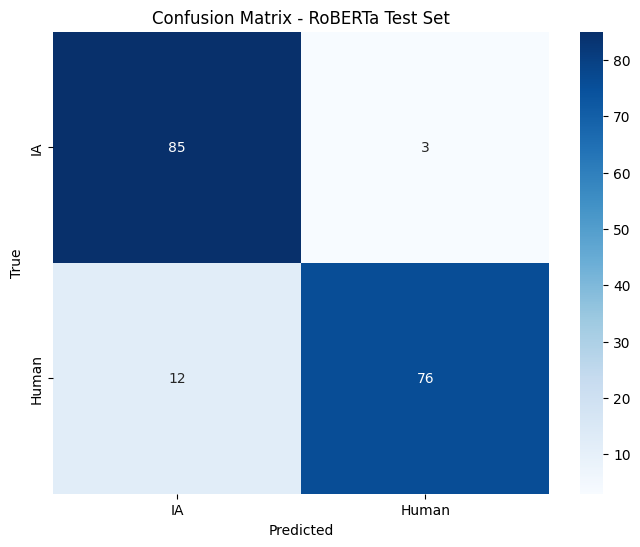

In [24]:
predictions, labels, metrics = trainer.predict(tokenized_dataset["test"])
predicted_classes = np.argmax(predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(labels, predicted_classes, target_names=["IA", "Human"], zero_division=0))

# Confusion Matrix
cm = confusion_matrix(labels, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["IA", "Human"], yticklabels=["IA", "Human"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - RoBERTa Test Set')
plt.show()